# 02 — Exploratory Data Analysis

Full exploratory pass on the tracheostomy-timing cohorts built by `01_merge_extract.ipynb`,
feeding the RQ in `RESEARCH_PROTOCOL.md`. Reads `derived/sati_q_cohort.parquet` and
`derived/anzpicr_cohort.parquet` **read-only** — never writes back to them.

Env: `data_science` conda env.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.dpi'] = 100

DERIVED_DIR = "derived"
SATI_DIR = "SATI-Q_WFPICCS_DATATHON_DATASET"
ANZ_DIR = "ANZPICR_WFPICCS_DATATHON_DATASET"

COLORS = {'SATI-Q': '#1f77b4', 'ANZPICR': '#d62728'}

## 0. Data-quality gate

Run first. If any assertion below fails, this notebook stops here and the failure is
reported back via `HANDOFF.md`, rather than proceeding to build analysis on top of a
broken assumption.

In [2]:
sati = pd.read_parquet(f"{DERIVED_DIR}/sati_q_cohort.parquet")
anz = pd.read_parquet(f"{DERIVED_DIR}/anzpicr_cohort.parquet")

required_cols = ['registry', 'age', 'sex', 'los_days', 'mech_vent', 'mortality', 'readmission',
                  'severity_score', 'severity_prob', 'days_to_trach', 'eligible_for_timing_analysis']
for name, df in [('sati_q_cohort', sati), ('anzpicr_cohort', anz)]:
    missing_required = [c for c in required_cols if c not in df.columns]
    assert not missing_required, f"{name} is missing required columns: {missing_required}"
    id_present = any(c in df.columns for c in ['TIPODNI', 'DNI', 'DSiteID', 'ICU_NO', 'DURNo'])
    assert id_present, f"{name} has no recognisable source id columns"
print("Required columns present in both cohort tables: OK")
print(f"sati_q_cohort: {sati.shape}, anzpicr_cohort: {anz.shape}")

Required columns present in both cohort tables: OK
sati_q_cohort: (2021, 33), anzpicr_cohort: (175, 30)


### 0.1 Missingness, by registry

In [3]:
def missingness_table(df, cols):
    return (df[cols].isna().mean() * 100).round(1).rename('% missing')

miss_cols = ['age', 'sex', 'los_days', 'hosp_los_days', 'mech_vent', 'mortality', 'readmission',
             'severity_score', 'severity_prob', 'days_to_trach']
miss = pd.DataFrame({
    'SATI-Q (all new-trach)': missingness_table(sati, miss_cols),
    'ANZPICR (all new-trach)': missingness_table(anz, miss_cols),
})
miss

,SATI-Q (all new-trach),ANZPICR (all new-trach)
age,0.0,0.0
sex,0.0,0.0
los_days,0.0,0.0
hosp_los_days,86.8,6.3
mech_vent,0.0,0.0
mortality,0.1,0.0
readmission,0.0,0.0
severity_score,0.4,100.0
severity_prob,0.4,0.0
days_to_trach,4.0,0.0


### 0.2 Re-derived exclusion funnel (cross-check against Task 1's reported numbers)

Recomputed directly from the raw admission/diagnosis files here, independently of
`01_merge_extract.ipynb`'s own printed funnel — if the two disagree, that's a bug
in one of the two notebooks, caught immediately rather than silently drifting.

In [4]:
def to_flag(s):
    return (s.astype(str).str.strip().str.upper()
            .map({'S': 1, 'SI': 1, 'N': 0, 'NO': 0, '1': 1, '0': 0, 'TRUE': 1, 'FALSE': 0}))

fv_raw = pd.read_csv(f"{SATI_DIR}/FIVARAPA_2015_2025.csv", encoding='utf-8-sig',
                     usecols=['TRAQ', 'TRAQI'])
sati_n_total = len(fv_raw)
sati_n_trach = (to_flag(fv_raw['TRAQ']) == 1).sum()
sati_n_new = ((to_flag(fv_raw['TRAQ']) == 1) & (to_flag(fv_raw['TRAQI']) == 0)).sum()
sati_n_eligible = int(sati['eligible_for_timing_analysis'].sum())

adm_key_only = pd.read_csv(f"{ANZ_DIR}/ANZPICR_ADM.csv", encoding='utf-8-sig',
                           usecols=['DSiteID', 'ICU_NO', 'DURNo'])
diag_raw = pd.read_csv(f"{ANZ_DIR}/ANZPICR_DIAG.csv", encoding='utf-8-sig')
anz_n_total = len(adm_key_only)
anz_trach_raw = diag_raw[diag_raw['ADX'] == 1506]
anz_n_trach = anz_trach_raw.drop_duplicates(subset=['DSiteID', 'ICU_NO', 'DURNo']).shape[0]
anz_n_new = anz_trach_raw[anz_trach_raw['ADX_CAT'] == 3].drop_duplicates(
    subset=['DSiteID', 'ICU_NO', 'DURNo']).shape[0]
anz_n_eligible = int(anz['eligible_for_timing_analysis'].sum())

funnel = pd.DataFrame({
    'SATI-Q': [sati_n_total, sati_n_trach, sati_n_new, sati_n_eligible],
    'ANZPICR': [anz_n_total, anz_n_trach, anz_n_new, anz_n_eligible],
}, index=['Total PICU admissions', 'Any tracheostomy', 'New tracheostomy', 'Eligible for timing analysis'])

assert sati_n_new == len(sati), (
    f"SATI-Q: re-derived new-trach count ({sati_n_new}) != rows in sati_q_cohort.parquet "
    f"({len(sati)}) -- Task 1's output no longer matches the raw data.")
assert anz_n_new == len(anz), (
    f"ANZPICR: re-derived new-trach count ({anz_n_new}) != rows in anzpicr_cohort.parquet "
    f"({len(anz)}) -- Task 1's output no longer matches the raw data.")
print("Funnel numbers match Task 1's parquet outputs exactly: OK")
funnel

Funnel numbers match Task 1's parquet outputs exactly: OK


,SATI-Q,ANZPICR
Total PICU admissions,87770,122622
Any tracheostomy,4413,488
New tracheostomy,2021,175
Eligible for timing analysis,1136,175


### 0.3 Range-check `days_to_trach`

`eligible_for_timing_analysis` rows should have no negative `days_to_trach` by
construction (Task 1 excludes negatives from eligibility) — checked here directly
rather than assumed. Note the *full* column can still contain negatives for
**ineligible** rows: Task 1 deliberately keeps those rows (with the flag set
`False`) rather than dropping them, so a negative value outside the eligible
subset is expected, not a bug.

In [5]:
sati_elig = sati[sati['eligible_for_timing_analysis']]
anz_elig = anz[anz['eligible_for_timing_analysis']]

sati_neg = (sati_elig['days_to_trach'] < 0).sum()
anz_neg = (anz_elig['days_to_trach'] < 0).sum()
print(f"Negative days_to_trach among ELIGIBLE rows -- SATI-Q: {sati_neg}, ANZPICR: {anz_neg}")
assert sati_neg == 0 and anz_neg == 0, (
    "STOP: negative days_to_trach found among eligible rows -- do not proceed to analysis, "
    "report this back under 'From VSCode Claude Code' in HANDOFF.md instead.")
print("Range check passed: no negative days_to_trach among eligible rows in either registry.")

Negative days_to_trach among ELIGIBLE rows -- SATI-Q: 0, ANZPICR: 0
Range check passed: no negative days_to_trach among eligible rows in either registry.


## 1. Cohort description ("Table 1")

Timing-eligible cohort only (`eligible_for_timing_analysis`), by registry.

In [6]:
def iqr_str(s):
    s = s.dropna()
    if len(s) == 0:
        return "n/a"
    return f"{s.median():.1f} [{s.quantile(.25):.1f}-{s.quantile(.75):.1f}]"

def pct_str(s):
    s = s.dropna()
    if len(s) == 0:
        return "n/a"
    return f"{s.mean()*100:.1f}%"

def pct_missing(s):
    return f"{s.isna().mean()*100:.1f}%"

table1 = pd.DataFrame({
    'SATI-Q': {
        'N': len(sati_elig),
        'Age, years, median [IQR]': iqr_str(sati_elig['age']),
        'Sex, % female': pct_str(sati_elig['sex'].map({'F': 1, 'M': 0})),
        'Severity prob, median [IQR]': iqr_str(sati_elig['severity_prob']),
        'Severity prob, % missing': pct_missing(sati_elig['severity_prob']),
        'Mech vent, %': pct_str(sati_elig['mech_vent']),
        'ICU LOS, days, median [IQR]': iqr_str(sati_elig['los_days']),
        'Mortality, %': pct_str(sati_elig['mortality']),
        'Readmission, %': pct_str(sati_elig['readmission']),
    },
    'ANZPICR': {
        'N': len(anz_elig),
        'Age, years, median [IQR]': iqr_str(anz_elig['age']),
        'Sex, % female': pct_str(anz_elig['sex'].map({'F': 1, 'M': 0})),
        'Severity prob, median [IQR]': iqr_str(anz_elig['severity_prob']),
        'Severity prob, % missing': pct_missing(anz_elig['severity_prob']),
        'Mech vent, %': pct_str(anz_elig['mech_vent']),
        'ICU LOS, days, median [IQR]': iqr_str(anz_elig['los_days']),
        'Mortality, %': pct_str(anz_elig['mortality']),
        'Readmission, %': pct_str(anz_elig['readmission']),
    },
})
table1

,SATI-Q,ANZPICR
N,1136,175
"Age, years, median [IQR]",1.8 [0.4-6.2],3.0 [0.0-12.0]
"Sex, % female",38.3%,45.7%
"Severity prob, median [IQR]",0.0 [0.0-0.1],0.0 [0.0-0.0]
"Severity prob, % missing",0.4%,0.0%
"Mech vent, %",96.5%,98.3%
"ICU LOS, days, median [IQR]",37.0 [21.0-64.0],53.0 [27.8-87.9]
"Mortality, %",7.4%,9.1%
"Readmission, %",4.5%,13.1%


### 1.1 Denominator: trach-timing cohort as a fraction of all PICU admissions

Reuses the raw admission counts from §0.2's re-derived funnel (same logic as the
original standalone `WFPICCS_Trach_EDA.ipynb`) rather than recomputing from scratch.

In [7]:
denom = pd.DataFrame({
    'SATI-Q': [sati_n_total, sati_n_new, sati_n_eligible, f"{sati_n_eligible/sati_n_total*100:.2f}%"],
    'ANZPICR': [anz_n_total, anz_n_new, anz_n_eligible, f"{anz_n_eligible/anz_n_total*100:.2f}%"],
}, index=['Total PICU admissions', 'New tracheostomy admissions', 'Timing-eligible',
          '% of all admissions (timing-eligible)'])
denom

,SATI-Q,ANZPICR
Total PICU admissions,87770,122622
New tracheostomy admissions,2021,175
Timing-eligible,1136,175
% of all admissions (timing-eligible),1.29%,0.14%


## 2. Exposure: distribution of `days_to_trach`

Timing-eligible cohort only.

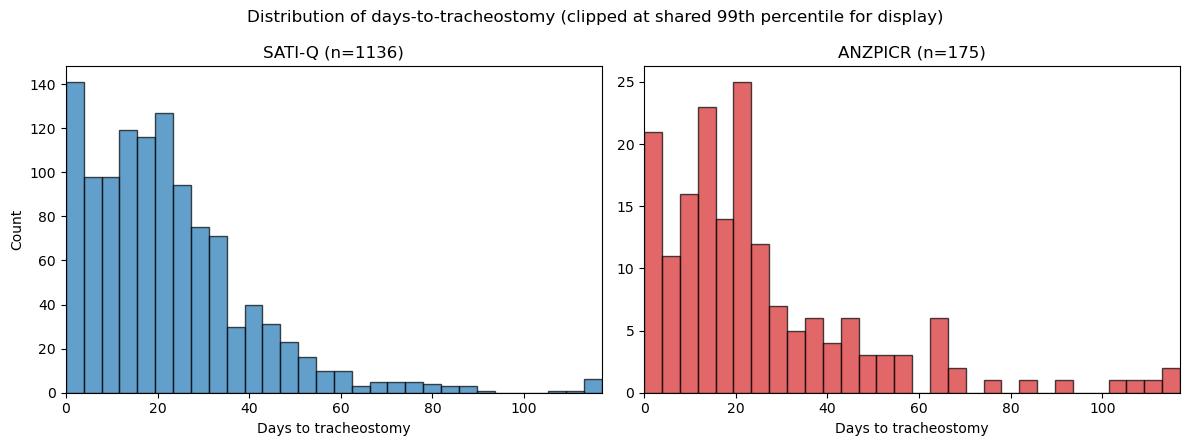

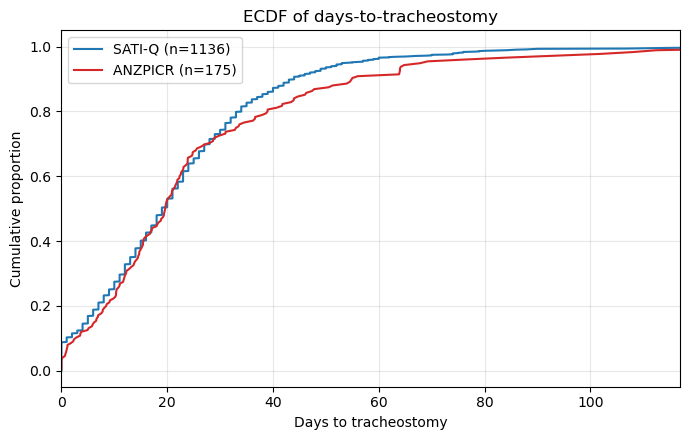

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
xmax = max(sati_elig['days_to_trach'].quantile(.99), anz_elig['days_to_trach'].quantile(.99))

for ax, (name, df) in zip(axes, [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]):
    d = df['days_to_trach'].clip(upper=xmax)
    ax.hist(d, bins=30, color=COLORS[name], alpha=0.7, edgecolor='black')
    ax.set_title(f'{name} (n={len(df)})')
    ax.set_xlabel('Days to tracheostomy')
    ax.set_xlim(0, xmax)
axes[0].set_ylabel('Count')
fig.suptitle('Distribution of days-to-tracheostomy (clipped at shared 99th percentile for display)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, df in [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]:
    d = np.sort(df['days_to_trach'].dropna())
    y = np.arange(1, len(d) + 1) / len(d)
    ax.plot(d, y, label=f'{name} (n={len(d)})', color=COLORS[name])
ax.set_xlim(0, xmax)
ax.set_xlabel('Days to tracheostomy')
ax.set_ylabel('Cumulative proportion')
ax.set_title('ECDF of days-to-tracheostomy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
desc = pd.DataFrame({
    'SATI-Q': sati_elig['days_to_trach'].describe(),
    'ANZPICR': anz_elig['days_to_trach'].describe(),
}).round(2)
desc

,SATI-Q,ANZPICR
count,1136.00,175.00
mean,51.23,26.46
std,975.60,28.41
min,0.00,0.00
25%,9.00,10.62
50%,19.00,19.67
75%,31.00,33.23
max,32898.00,250.00


### 2.1 Cross-registry boxplot

**Caveat on formal testing:** SATI-Q and ANZPICR differ in era, case-mix, and
national practice (see §6's comparability check) — a significant Mann-Whitney U
result here would describe *that these two samples differ*, not that timing
practice itself differs in a way that's meaningful without controlling for those
confounders. Reported below for completeness, not as evidence either way on the
RQ.

/var/folders/pj/8wyqm7hs2hddpd1kx4kk_c4h0000gn/T/ipykernel_12183/760194649.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['SATI-Q', 'ANZPICR'], patch_artist=True)


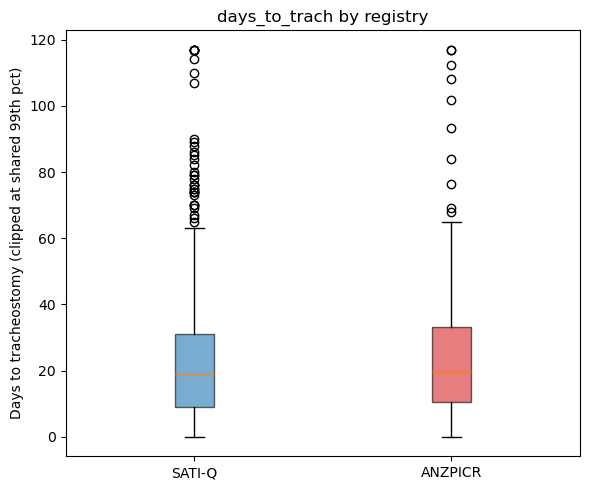

Mann-Whitney U = 95022, p = 0.3475
(see caveat above -- not a clean test of a meaningful practice difference given differing populations/eras between registries)


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
box_data = [sati_elig['days_to_trach'].clip(upper=xmax).dropna(),
            anz_elig['days_to_trach'].clip(upper=xmax).dropna()]
bp = ax.boxplot(box_data, labels=['SATI-Q', 'ANZPICR'], patch_artist=True)
for patch, name in zip(bp['boxes'], ['SATI-Q', 'ANZPICR']):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.6)
ax.set_ylabel('Days to tracheostomy (clipped at shared 99th pct)')
ax.set_title('days_to_trach by registry')
plt.tight_layout()
plt.show()

u_stat, p_val = stats.mannwhitneyu(sati_elig['days_to_trach'].dropna(),
                                    anz_elig['days_to_trach'].dropna(),
                                    alternative='two-sided')
print(f"Mann-Whitney U = {u_stat:.0f}, p = {p_val:.4g}")
print("(see caveat above -- not a clean test of a meaningful practice difference "
      "given differing populations/eras between registries)")

### 2.2 Sensitivity: group sizes at candidate early/late cutoffs

Informs (does not resolve) `RESEARCH_PROTOCOL.md`'s open question on the early/late
cutoff.

In [11]:
cutoffs = [3, 5, 7, 10, 14, 21]
sens_rows = []
for c in cutoffs:
    row = {'cutoff (days)': c}
    for name, df in [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]:
        d = df['days_to_trach'].dropna()
        row[f'{name} early'] = int((d < c).sum())
        row[f'{name} late'] = int((d >= c).sum())
    sens_rows.append(row)
sensitivity = pd.DataFrame(sens_rows).set_index('cutoff (days)')
sensitivity

,SATI-Q early,SATI-Q late,ANZPICR early,ANZPICR late
cutoff (days),,,,
3,131,1005,18,157
5,165,971,22,153
7,214,922,30,145
10,285,851,39,136
14,398,738,59,116
21,603,533,97,78


### 2.3 Implausible outliers: `days_to_trach > los_days`

Placement recorded after the whole PICU stay ended — impossible. Task 1 already
flagged this for SATI-Q (3 rows, one a clear `TRAQFI` year-2109 typo); re-checked
independently here across both registries' eligible cohorts.

In [12]:
for name, df in [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]:
    viol = df[df['days_to_trach'] > df['los_days']]
    print(f"{name}: {len(viol)} eligible rows with days_to_trach > los_days")
    if len(viol):
        cols = [c for c in ['days_to_trach', 'los_days'] if c in viol.columns]
        print(viol[cols].to_string())

SATI-Q: 3 eligible rows with days_to_trach > los_days
      days_to_trach  los_days
494            36.0         8
743           107.0       105
1653        32898.0        50
ANZPICR: 0 eligible rows with days_to_trach > los_days


## 3. Outcome distributions

Timing-eligible cohort, by registry. Ventilation *duration* is only available for
ANZPICR (`INV_HRS`/`MECHVENT_HRS`, added to Task 1's output for this purpose) — SATI-Q's
FIVARAPA has no vent-duration field (only the `ARM` yes/no flag baked into `mech_vent`);
joining `FiPracticaARM` to get one was out of scope for Task 1, flagged as an open item.

In [13]:
outcome_tbl = pd.DataFrame({
    'SATI-Q': {
        'Mortality, %': pct_str(sati_elig['mortality']),
        'ICU LOS, days, median [IQR]': iqr_str(sati_elig['los_days']),
        'Vent duration, hrs, median [IQR]': 'not available',
        'Readmission, %': pct_str(sati_elig['readmission']),
    },
    'ANZPICR': {
        'Mortality, %': pct_str(anz_elig['mortality']),
        'ICU LOS, days, median [IQR]': iqr_str(anz_elig['los_days']),
        'Vent duration, hrs, median [IQR]': iqr_str(anz_elig['INV_HRS']),
        'Readmission, %': pct_str(anz_elig['readmission']),
    },
})
outcome_tbl

,SATI-Q,ANZPICR
"Mortality, %",7.4%,9.1%
"ICU LOS, days, median [IQR]",37.0 [21.0-64.0],53.0 [27.8-87.9]
"Vent duration, hrs, median [IQR]",not available,936.4 [434.1-1752.4]
"Readmission, %",4.5%,13.1%


/var/folders/pj/8wyqm7hs2hddpd1kx4kk_c4h0000gn/T/ipykernel_12183/3929315183.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([sati_elig['los_days'].clip(upper=los_max).dropna(),


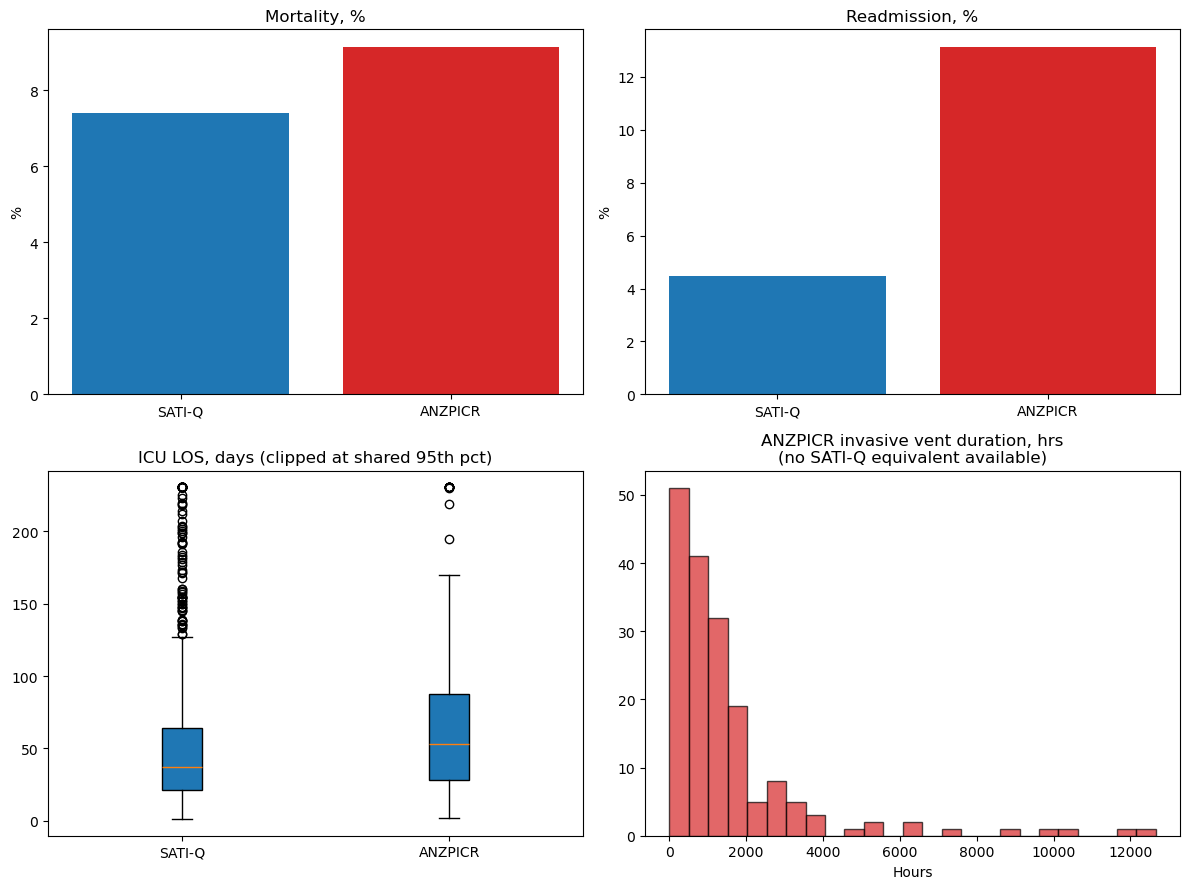

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

mort = pd.DataFrame({'SATI-Q': [sati_elig['mortality'].mean() * 100],
                      'ANZPICR': [anz_elig['mortality'].mean() * 100]})
axes[0, 0].bar(mort.columns, mort.iloc[0], color=[COLORS[c] for c in mort.columns])
axes[0, 0].set_title('Mortality, %')
axes[0, 0].set_ylabel('%')

readm = pd.DataFrame({'SATI-Q': [sati_elig['readmission'].mean() * 100],
                       'ANZPICR': [anz_elig['readmission'].mean(skipna=True) * 100]})
axes[0, 1].bar(readm.columns, readm.iloc[0], color=[COLORS[c] for c in readm.columns])
axes[0, 1].set_title('Readmission, %')
axes[0, 1].set_ylabel('%')

los_max = max(sati_elig['los_days'].quantile(.95), anz_elig['los_days'].quantile(.95))
axes[1, 0].boxplot([sati_elig['los_days'].clip(upper=los_max).dropna(),
                     anz_elig['los_days'].clip(upper=los_max).dropna()],
                    labels=['SATI-Q', 'ANZPICR'], patch_artist=True)
axes[1, 0].set_title('ICU LOS, days (clipped at shared 95th pct)')

axes[1, 1].hist(anz_elig['INV_HRS'].dropna(), bins=25, color=COLORS['ANZPICR'],
                 alpha=0.7, edgecolor='black')
axes[1, 1].set_title('ANZPICR invasive vent duration, hrs\n(no SATI-Q equivalent available)')
axes[1, 1].set_xlabel('Hours')

plt.tight_layout()
plt.show()

## 4. Confounder relationships with the exposure

Are sicker / older kids trached earlier or later? Timing-eligible cohort.

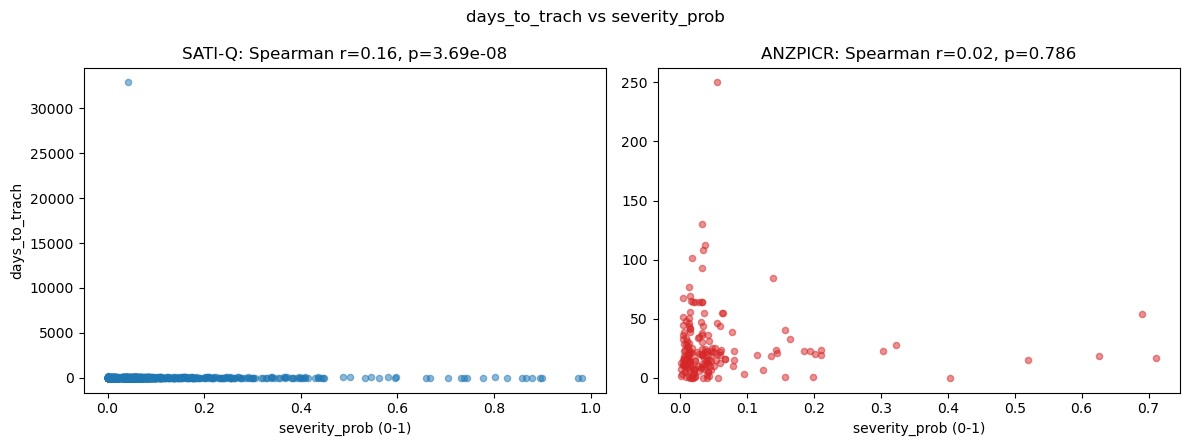

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, df) in zip(axes, [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]):
    d = df.dropna(subset=['days_to_trach', 'severity_prob'])
    ax.scatter(d['severity_prob'], d['days_to_trach'], alpha=0.5, s=20, color=COLORS[name])
    if len(d) > 2:
        r, p = stats.spearmanr(d['severity_prob'], d['days_to_trach'])
        ax.set_title(f'{name}: Spearman r={r:.2f}, p={p:.3g}')
    else:
        ax.set_title(f'{name}: n too small')
    ax.set_xlabel('severity_prob (0-1)')
axes[0].set_ylabel('days_to_trach')
fig.suptitle('days_to_trach vs severity_prob')
plt.tight_layout()
plt.show()

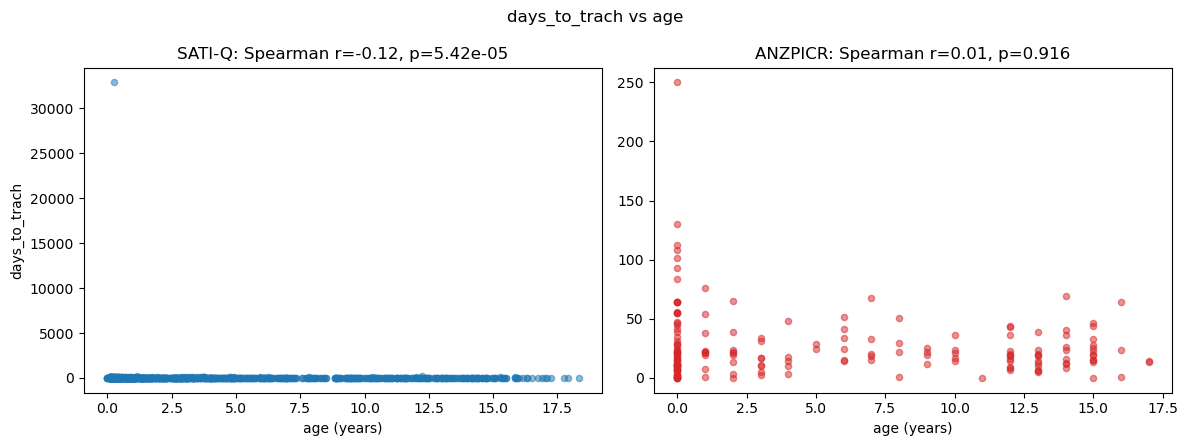

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, df) in zip(axes, [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]):
    d = df.dropna(subset=['days_to_trach', 'age'])
    ax.scatter(d['age'], d['days_to_trach'], alpha=0.5, s=20, color=COLORS[name])
    if len(d) > 2:
        r, p = stats.spearmanr(d['age'], d['days_to_trach'])
        ax.set_title(f'{name}: Spearman r={r:.2f}, p={p:.3g}')
    else:
        ax.set_title(f'{name}: n too small')
    ax.set_xlabel('age (years)')
axes[0].set_ylabel('days_to_trach')
fig.suptitle('days_to_trach vs age')
plt.tight_layout()
plt.show()

### 4.1 `days_to_trach` by admission category and diagnosis group

`elective` (SATI-Q, from `FiPIM3`/`FiPim`'s `ADMISIONELECTIVA`) and `ELECTIVE`
(ANZPICR) — both 1=elective, 0=non-elective/emergency.

/var/folders/pj/8wyqm7hs2hddpd1kx4kk_c4h0000gn/T/ipykernel_12183/2739713701.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(sati_elective_groups, labels=sati_elective_labels, patch_artist=True)
/var/folders/pj/8wyqm7hs2hddpd1kx4kk_c4h0000gn/T/ipykernel_12183/2739713701.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(anz_elective_groups, labels=anz_elective_labels, patch_artist=True)


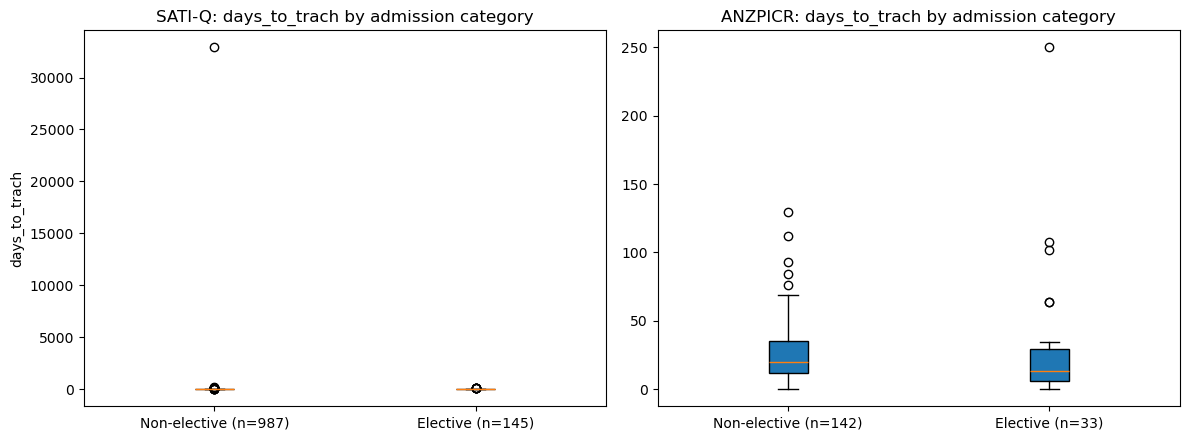

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sati_elective_groups = [g['days_to_trach'].dropna() for _, g in sati_elig.groupby('elective')]
sati_elective_labels = [f"{'Elective' if k==1 else 'Non-elective'} (n={len(g)})"
                         for k, g in sati_elig.groupby('elective')]
axes[0].boxplot(sati_elective_groups, labels=sati_elective_labels, patch_artist=True)
axes[0].set_title('SATI-Q: days_to_trach by admission category')
axes[0].set_ylabel('days_to_trach')

anz_elective_groups = [g['days_to_trach'].dropna() for _, g in anz_elig.groupby('ELECTIVE')]
anz_elective_labels = [f"{'Elective' if k==1 else 'Non-elective'} (n={len(g)})"
                        for k, g in anz_elig.groupby('ELECTIVE')]
axes[1].boxplot(anz_elective_groups, labels=anz_elective_labels, patch_artist=True)
axes[1].set_title('ANZPICR: days_to_trach by admission category')
plt.tight_layout()
plt.show()

In [18]:
print("SATI-Q: days_to_trach by diagnosis_group (PATING)")
print(sati_elig.groupby('diagnosis_group')['days_to_trach'].describe()[['count', 'mean', '50%']]
      .round(1).sort_values('count', ascending=False))
print()
print("ANZPICR: days_to_trach by top-5 PDX codes (diagnosis code, not a category -- "
      "no SATI-Q-equivalent grouping exists for PDX, shown as-is)")
top_pdx = anz_elig['PDX'].value_counts().head(5).index
print(anz_elig[anz_elig['PDX'].isin(top_pdx)].groupby('PDX')['days_to_trach']
      .describe()[['count', 'mean', '50%']].round(1))

SATI-Q: days_to_trach by diagnosis_group (PATING)
                 count  mean   50%
diagnosis_group                   
Respiratorio     537.0  83.4  20.0
Neurológico      208.0  22.0  19.0
Otros            126.0  25.4  21.5
Postquirúrgico   113.0  20.1  15.0
Causa Externa     67.0  19.7  17.0
Cardiológico      37.0  28.5  23.0

ANZPICR: days_to_trach by top-5 PDX codes (diagnosis code, not a category -- no SATI-Q-equivalent grouping exists for PDX, shown as-is)
     count  mean   50%
PDX                   
410   10.0  16.1  10.9
465    7.0  34.0  25.6
468   16.0  38.2  16.5
802   10.0  17.2  17.7
832    9.0  24.5  19.6


## 5. Exploratory timing-vs-outcome views — NOT the study's answer to the RQ

> **Warning (read `RESEARCH_PROTOCOL.md`'s "immortal time / survivorship bias"
> section before interpreting anything below).** Children who get an *early*
> tracheostomy cannot, by definition, have died or been discharged before it was
> placed; children who go on to a *late* tracheostomy have already "survived" the
> intervening period on the ventilator. Naively comparing mortality between early-
> and late-trach groups is biased toward making early tracheostomy look protective.
> Everything in this section is descriptive/exploratory only. The defensible answer
> requires a landmark analysis or time-varying (Cox) model with trach as a
> time-dependent covariate — deferred to stage 3 of the protocol, not built here.

/var/folders/pj/8wyqm7hs2hddpd1kx4kk_c4h0000gn/T/ipykernel_12183/2556288017.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return d.groupby('quintile')['mortality'].agg(['mean', 'count'])
/var/folders/pj/8wyqm7hs2hddpd1kx4kk_c4h0000gn/T/ipykernel_12183/2556288017.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return d.groupby('quintile')['mortality'].agg(['mean', 'count'])


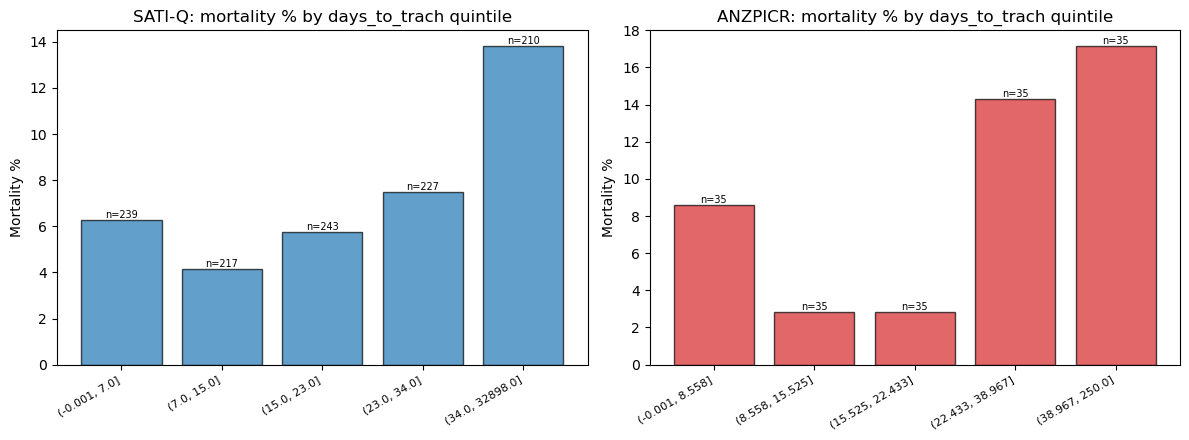

In [19]:
def mortality_by_quintile(df):
    d = df.dropna(subset=['days_to_trach', 'mortality']).copy()
    try:
        d['quintile'] = pd.qcut(d['days_to_trach'], 5, duplicates='drop')
    except ValueError:
        return None
    return d.groupby('quintile')['mortality'].agg(['mean', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, df) in zip(axes, [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]):
    q = mortality_by_quintile(df)
    if q is not None:
        ax.bar(range(len(q)), q['mean'] * 100, color=COLORS[name], alpha=0.7, edgecolor='black')
        ax.set_xticks(range(len(q)))
        ax.set_xticklabels([str(i) for i in q.index], rotation=30, ha='right', fontsize=8)
        for i, n in enumerate(q['count']):
            ax.annotate(f'n={n}', (i, q['mean'].iloc[i] * 100), ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{name}: mortality % by days_to_trach quintile')
    ax.set_ylabel('Mortality %')
plt.tight_layout()
plt.show()

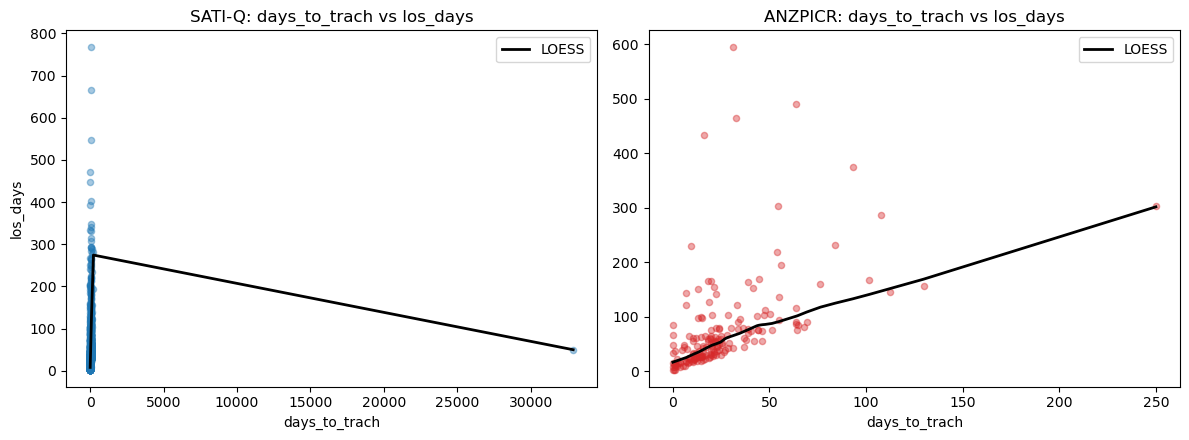

In [20]:
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, df) in zip(axes, [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]):
    d = df.dropna(subset=['days_to_trach', 'los_days'])
    ax.scatter(d['days_to_trach'], d['los_days'], alpha=0.4, s=20, color=COLORS[name])
    if len(d) > 10:
        smoothed = lowess(d['los_days'], d['days_to_trach'], frac=0.4)
        ax.plot(smoothed[:, 0], smoothed[:, 1], color='black', linewidth=2, label='LOESS')
        ax.legend()
    ax.set_title(f'{name}: days_to_trach vs los_days')
    ax.set_xlabel('days_to_trach')
axes[0].set_ylabel('los_days')
plt.tight_layout()
plt.show()

### 5.1 Descriptive Kaplan-Meier-style curve: ICU discharge/survival, early vs late trach at 7-day cutoff

Simple product-limit estimator (time = `los_days`, event = `mortality`, censored =
discharged alive), computed manually here rather than via a survival-analysis
library, since this is explicitly a *descriptive* curve, not the study's real
time-to-event model. 7-day cutoff is provisional (see `RESEARCH_PROTOCOL.md`'s open
questions) — used here only to illustrate the shape of the exploratory comparison.

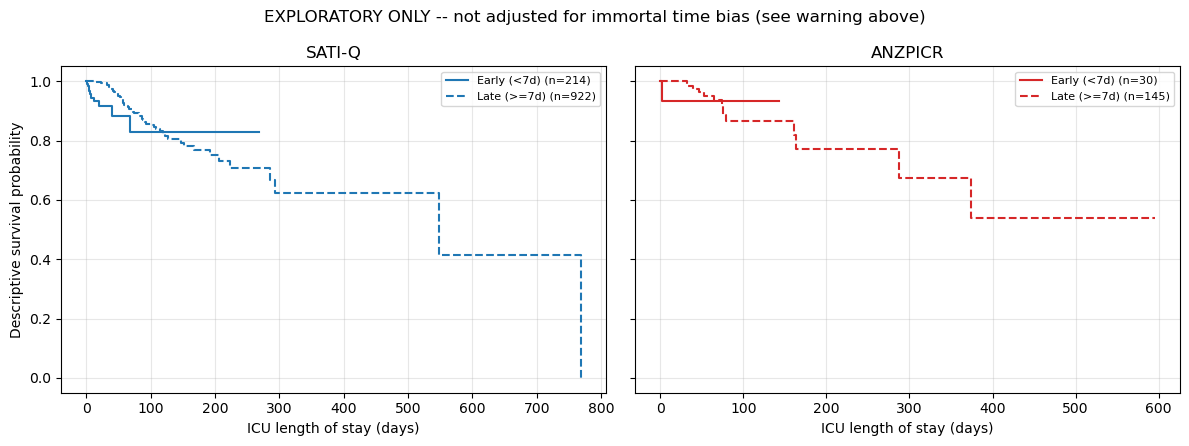

In [21]:
def km_curve(times, events):
    d = pd.DataFrame({'t': times, 'e': events}).dropna().sort_values('t')
    surv, surv_t, surv_p = 1.0, [0.0], [1.0]
    for t in d['t'].unique():
        at_risk = (d['t'] >= t).sum()
        deaths = d.loc[d['t'] == t, 'e'].sum()
        if at_risk > 0:
            surv *= (1 - deaths / at_risk)
        surv_t.append(float(t))
        surv_p.append(surv)
    return surv_t, surv_p

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (name, df) in zip(axes, [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]):
    for early, label, style in [(True, 'Early (<7d)', '-'), (False, 'Late (>=7d)', '--')]:
        sub = df[df['days_to_trach'] < 7] if early else df[df['days_to_trach'] >= 7]
        if len(sub) < 2:
            continue
        t, p = km_curve(sub['los_days'], sub['mortality'])
        ax.step(t, p, where='post', linestyle=style, label=f'{label} (n={len(sub)})', color=COLORS[name])
    ax.set_title(f'{name}')
    ax.set_xlabel('ICU length of stay (days)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Descriptive survival probability')
fig.suptitle('EXPLORATORY ONLY -- not adjusted for immortal time bias (see warning above)')
plt.tight_layout()
plt.show()

## 6. Cross-registry comparability check

Before anyone considers pooling SATI-Q and ANZPICR, how similar are the two
timing-eligible cohorts on the variables that would confound a naive comparison?

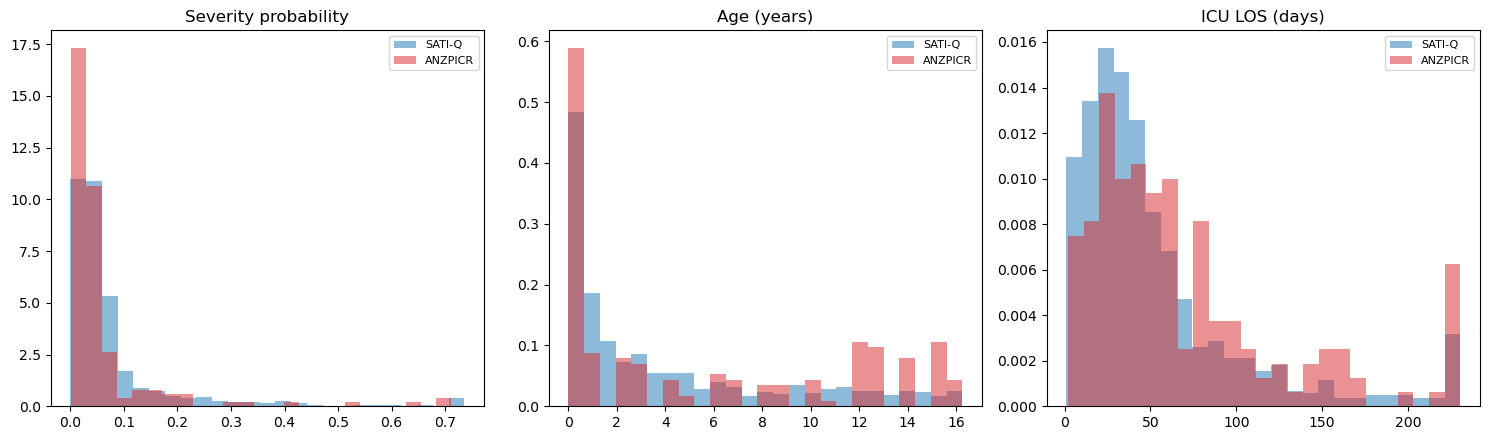

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, title, clip_q in [(axes[0], 'severity_prob', 'Severity probability', 0.99),
                                 (axes[1], 'age', 'Age (years)', 0.99),
                                 (axes[2], 'los_days', 'ICU LOS (days)', 0.95)]:
    cap = max(sati_elig[col].quantile(clip_q), anz_elig[col].quantile(clip_q))
    for name, df in [('SATI-Q', sati_elig), ('ANZPICR', anz_elig)]:
        d = df[col].clip(upper=cap).dropna()
        ax.hist(d, bins=25, alpha=0.5, density=True, label=name, color=COLORS[name])
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Output summary

This notebook is **read-only** with respect to `derived/*.parquet` — nothing below
writes back to Task 1's outputs.

In [23]:
print("FINDINGS")
print("-" * 70)
findings = [
    f"SATI-Q timing-eligible cohort: n={len(sati_elig)} ({sati_n_eligible/sati_n_total*100:.2f}% "
    f"of all admissions); ANZPICR: n={len(anz_elig)} ({anz_n_eligible/anz_n_total*100:.3f}% of all "
    f"admissions) -- SATI-Q's trach-timing cohort is proportionally far larger, consistent with "
    f"the two registries' very different case-mix/era (see §6).",
    f"Median days_to_trach: SATI-Q {sati_elig['days_to_trach'].median():.1f}d vs ANZPICR "
    f"{anz_elig['days_to_trach'].median():.1f}d -- descriptive only, not adjusted for "
    f"case-mix (§2.1 caveat).",
    f"Mortality in the trach-timing cohort: SATI-Q {sati_elig['mortality'].mean()*100:.1f}% vs "
    f"ANZPICR {anz_elig['mortality'].mean()*100:.1f}% -- both far above general-PICU mortality, "
    f"consistent with this being a high-acuity subgroup by construction.",
    "Severity, age, and LOS distributions differ visibly between registries (§6) -- pooling "
    "without a stratified/random-effects approach would confound registry with case-mix, as "
    "RESEARCH_PROTOCOL.md's Design section already anticipates.",
    "The exploratory quintile-mortality and KM views (§5) show the shape of the naive "
    "association but are explicitly NOT usable as evidence on the RQ given immortal time bias "
    "-- stage 3's landmark/time-varying model is required before drawing any conclusion.",
]
for i, f in enumerate(findings, 1):
    print(f"{i}. {f}\n")

print("DATA-QUALITY ISSUES / OPEN QUESTIONS (beyond those already in RESEARCH_PROTOCOL.md)")
print("-" * 70)
open_qs = [
    "Mechanical ventilation *duration* has no SATI-Q equivalent (only the ARM yes/no flag) -- "
    "joining FiPracticaARM would be needed to compare vent duration cross-registry at all.",
    "ANZPICR's timing-eligible cohort (n=175) is over 6x smaller than SATI-Q's (n=1,136) -- any "
    "cross-registry comparison will be underpowered on the ANZPICR side regardless of method.",
    "SATI-Q severity_prob has a nontrivial missing rate (rows with neither FiPIM3 nor FiPim "
    "records) -- see §0.1/§1's missingness figures for the exact rate; worth deciding whether "
    "to impute or restrict the severity-adjusted analysis to complete cases.",
    "PDX (ANZPICR primary diagnosis) is a high-cardinality numeric code with no category "
    "mapping applied here -- would need the ANZPICR diagnosis dictionary's grouping (if one "
    "exists) to be genuinely comparable to SATI-Q's diagnosis_group.",
]
for i, q in enumerate(open_qs, 1):
    print(f"{i}. {q}\n")

FINDINGS
----------------------------------------------------------------------
1. SATI-Q timing-eligible cohort: n=1136 (1.29% of all admissions); ANZPICR: n=175 (0.143% of all admissions) -- SATI-Q's trach-timing cohort is proportionally far larger, consistent with the two registries' very different case-mix/era (see §6).

2. Median days_to_trach: SATI-Q 19.0d vs ANZPICR 19.7d -- descriptive only, not adjusted for case-mix (§2.1 caveat).

3. Mortality in the trach-timing cohort: SATI-Q 7.4% vs ANZPICR 9.1% -- both far above general-PICU mortality, consistent with this being a high-acuity subgroup by construction.

4. Severity, age, and LOS distributions differ visibly between registries (§6) -- pooling without a stratified/random-effects approach would confound registry with case-mix, as RESEARCH_PROTOCOL.md's Design section already anticipates.

5. The exploratory quintile-mortality and KM views (§5) show the shape of the naive association but are explicitly NOT usable as evidence o